In [1]:
# Basic packages
import pandas as pd
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier


from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


In [2]:
# Load your training dataset (replace with correct filename)
df_train = pd.read_csv("asthma_train.csv")

# Separate features and target
X = df_train.drop(columns=["Diagnosis"])
y = df_train["Diagnosis"]


In [3]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Check new class distribution
print("✅ Balanced class counts:\n", y_balanced.value_counts())


✅ Balanced class counts:
 Diagnosis
0    1814
1    1814
Name: count, dtype: int64


In [4]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
lr.fit(X_balanced, y_balanced)




LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [5]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_balanced, y_balanced)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [6]:

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_balanced, y_balanced)

GradientBoostingClassifier(random_state=42)

In [7]:
# Create VotingClassifier (Hybrid Model)
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('gb', gb)
    ],
    voting='soft'  # Uses predicted probabilities for averaging
)

# Train ensemble model on balanced data
voting_model.fit(X_balanced, y_balanced)

print("✅ Hybrid Voting Model Trained Successfully")


✅ Hybrid Voting Model Trained Successfully


In [8]:
# Load the testing dataset
df_test = pd.read_csv("asthma_test.csv")

# Split into features and target
X_test = df_test.drop(columns=["Diagnosis"])
y_test = df_test["Diagnosis"]


In [9]:
# Predictions
y_pred = voting_model.predict(X_test)
y_proba = voting_model.predict_proba(X_test)[:, 1]  # for AUC


In [10]:


print("🔹 Hybrid Voting Model Evaluation")

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {round(acc, 4)}")

# AUC Score
auc = roc_auc_score(y_test, y_proba)
print(f"📈 AUC Score: {round(auc, 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("📊 Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("📋 Classification Report:\n", report)


🔹 Hybrid Voting Model Evaluation
✅ Accuracy: 0.8831
📈 AUC Score: 0.6648
📊 Confusion Matrix:
 [[419  35]
 [ 21   4]]
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94       454
           1       0.10      0.16      0.12        25

    accuracy                           0.88       479
   macro avg       0.53      0.54      0.53       479
weighted avg       0.91      0.88      0.89       479



In [11]:
import shap

C:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf)  # You can also use voting_model.estimators_[1] if using hybrid

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot (for class 1)
shap.summary_plot(shap_values[1], X_test, plot_type="bar")

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

X_test shape: (479, 27)
SHAP values shape: (479, 27, 2)


<Figure size 640x480 with 0 Axes>

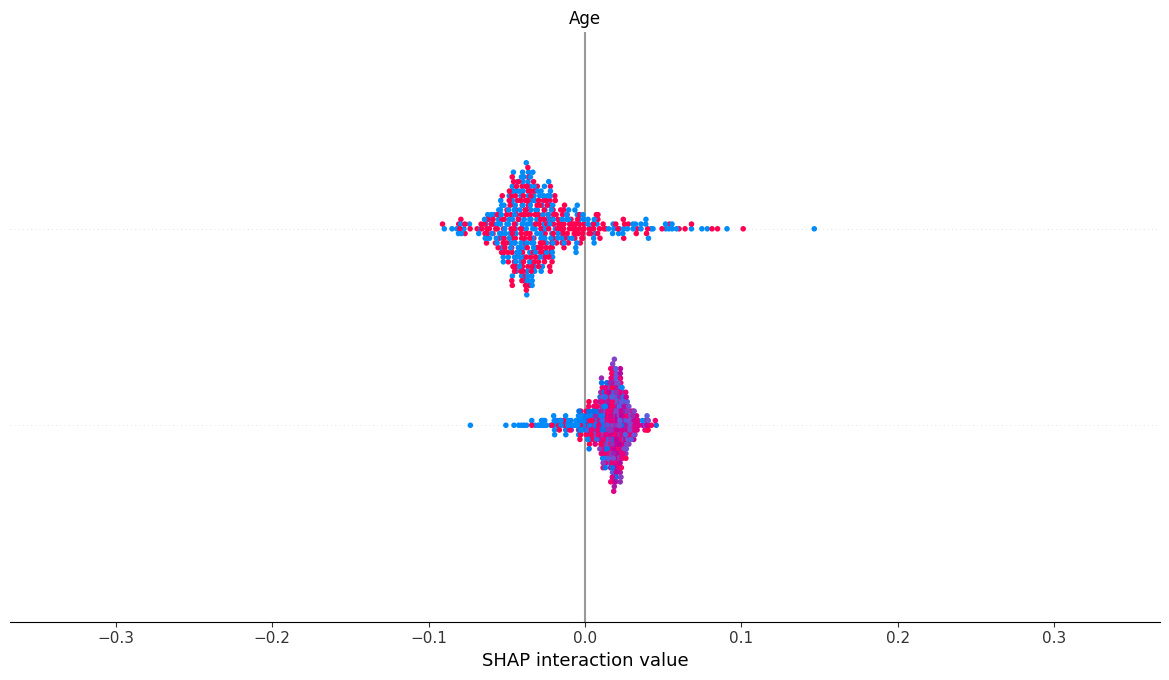

In [13]:
import shap
import numpy as np

# Use Random Forest or a specific estimator if using hybrid
explainer = shap.TreeExplainer(rf)  # or voting_model.named_estimators_['rf']

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Check shape
print("X_test shape:", X_test.shape)
print("SHAP values shape:", np.array(shap_values).shape)

# Plot safely
if isinstance(shap_values, list) and len(shap_values) == 2:
    # Binary classification: shap_values[1] for class 1
    shap.summary_plot(shap_values[1], X_test, plot_type="bar")
else:
    shap.summary_plot(shap_values, X_test, plot_type="bar")


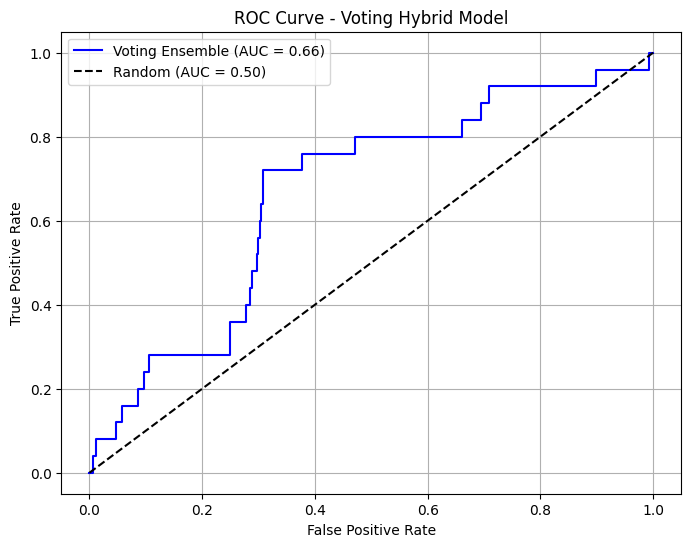

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get ROC curve data
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Voting Ensemble (AUC = %.2f)' % auc, color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Voting Hybrid Model')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
import joblib

# Save the hybrid VotingClassifier
joblib.dump(voting_model, "voting_hybrid_model.pkl")



['voting_hybrid_model.pkl']

In [16]:


print("✅ Hybrid model and scaler saved successfully.")


✅ Hybrid model and scaler saved successfully.
